In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("demand_forecasting.csv")

In [3]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [4]:
print(df.head())

        Date Store ID Product ID     Category Region  Inventory Level  \
0 2022-01-01     S001      P0001  Electronics  North              195   
1 2022-01-01     S001      P0002     Clothing  North              117   
2 2022-01-01     S001      P0003     Clothing  North              247   
3 2022-01-01     S001      P0004  Electronics  North              139   
4 2022-01-01     S001      P0005    Groceries  North              152   

   Units Sold  Units Ordered  Price  Discount Weather Condition  Promotion  \
0         102            252  72.72         5             Snowy          0   
1         117            249  80.16        15             Snowy          1   
2         114            612  62.94        10             Snowy          1   
3          45            102  87.63        10             Snowy          0   
4          65            271  54.41         0             Snowy          0   

   Competitor Pricing Seasonality  Epidemic  Demand  
0               85.73      Winter     

In [5]:
print(df.shape)

(76000, 16)


In [6]:
print(df.dtypes)

Date                  datetime64[us]
Store ID                         str
Product ID                       str
Category                         str
Region                           str
Inventory Level                int64
Units Sold                     int64
Units Ordered                  int64
Price                        float64
Discount                       int64
Weather Condition                str
Promotion                      int64
Competitor Pricing           float64
Seasonality                      str
Epidemic                       int64
Demand                         int64
dtype: object


In [7]:
# Date range check
print("Date Range:", df['Date'].min(), "to", df['Date'].max())

Date Range: 2022-01-01 00:00:00 to 2024-01-30 00:00:00


In [8]:
#SORT DATA
df = df.sort_values(["Product ID", "Date"])

In [9]:
df = df.drop_duplicates()

In [10]:
#FEATURE ENGINEERING:


# Time features
df['day'] = df['Date'].dt.day
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year
df['weekday'] = df['Date'].dt.weekday
df['weekofyear'] = df['Date'].dt.isocalendar().week
df['is_weekend'] = df['weekday'].isin([5,6]).astype(int)

In [11]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,...,Competitor Pricing,Seasonality,Epidemic,Demand,day,month,year,weekday,weekofyear,is_weekend
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,...,85.73,Winter,0,115,1,1,2022,5,52,1
20,2022-01-01,S002,P0001,Groceries,South,102,102,331,90.89,0,...,81.87,Winter,0,118,1,1,2022,5,52,1
40,2022-01-01,S003,P0001,Toys,East,182,109,193,16.85,10,...,15.48,Winter,0,112,1,1,2022,5,52,1
60,2022-01-01,S004,P0001,Groceries,West,215,85,287,10.47,0,...,11.51,Winter,0,81,1,1,2022,5,52,1
80,2022-01-01,S005,P0001,Groceries,North,182,75,198,11.46,5,...,9.92,Winter,0,84,1,1,2022,5,52,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75919,2024-01-30,S001,P0020,Furniture,North,333,54,248,112.50,5,...,120.88,Winter,0,73,30,1,2024,1,5,0
75939,2024-01-30,S002,P0020,Furniture,South,332,88,0,140.31,0,...,126.60,Winter,0,82,30,1,2024,1,5,0
75959,2024-01-30,S003,P0020,Clothing,East,113,73,0,70.60,10,...,69.21,Winter,0,96,30,1,2024,1,5,0
75979,2024-01-30,S004,P0020,Furniture,West,79,79,166,132.53,10,...,120.59,Winter,0,93,30,1,2024,1,5,0


In [12]:
# Price-based feature
df["Discounted Price"] = df["Price"] * (1 - df["Discount"] / 100)

In [13]:
#REMOVE DATA LEAKAGE
df = df.drop(columns=["Units Sold", "Units Ordered"], errors="ignore")

In [14]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Price,Discount,Weather Condition,Promotion,...,Seasonality,Epidemic,Demand,day,month,year,weekday,weekofyear,is_weekend,Discounted Price
0,2022-01-01,S001,P0001,Electronics,North,195,72.72,5,Snowy,0,...,Winter,0,115,1,1,2022,5,52,1,69.084
20,2022-01-01,S002,P0001,Groceries,South,102,90.89,0,Cloudy,0,...,Winter,0,118,1,1,2022,5,52,1,90.890
40,2022-01-01,S003,P0001,Toys,East,182,16.85,10,Sunny,0,...,Winter,0,112,1,1,2022,5,52,1,15.165
60,2022-01-01,S004,P0001,Groceries,West,215,10.47,0,Snowy,0,...,Winter,0,81,1,1,2022,5,52,1,10.470
80,2022-01-01,S005,P0001,Groceries,North,182,11.46,5,Snowy,0,...,Winter,0,84,1,1,2022,5,52,1,10.887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75919,2024-01-30,S001,P0020,Furniture,North,333,112.50,5,Snowy,0,...,Winter,0,73,30,1,2024,1,5,0,106.875
75939,2024-01-30,S002,P0020,Furniture,South,332,140.31,0,Snowy,0,...,Winter,0,82,30,1,2024,1,5,0,140.310
75959,2024-01-30,S003,P0020,Clothing,East,113,70.60,10,Sunny,0,...,Winter,0,96,30,1,2024,1,5,0,63.540
75979,2024-01-30,S004,P0020,Furniture,West,79,132.53,10,Snowy,0,...,Winter,0,93,30,1,2024,1,5,0,119.277


In [15]:
# LAG FEATURES
df['lag_1'] = df.groupby("Product ID")["Demand"].shift(1)
df['lag_7'] = df.groupby("Product ID")["Demand"].shift(7)

In [16]:
#Rolling mean (PER PRODUCT)
df['rolling_mean_7'] = (
    df.groupby("Product ID")["Demand"]
      .rolling(window=7)
      .mean()
      .reset_index(level=0, drop=True)
)

In [17]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Price,Discount,Weather Condition,Promotion,...,day,month,year,weekday,weekofyear,is_weekend,Discounted Price,lag_1,lag_7,rolling_mean_7
0,2022-01-01,S001,P0001,Electronics,North,195,72.72,5,Snowy,0,...,1,1,2022,5,52,1,69.084,NaN,NaN,NaN
20,2022-01-01,S002,P0001,Groceries,South,102,90.89,0,Cloudy,0,...,1,1,2022,5,52,1,90.890,115.0,NaN,NaN
40,2022-01-01,S003,P0001,Toys,East,182,16.85,10,Sunny,0,...,1,1,2022,5,52,1,15.165,118.0,NaN,NaN
60,2022-01-01,S004,P0001,Groceries,West,215,10.47,0,Snowy,0,...,1,1,2022,5,52,1,10.470,112.0,NaN,NaN
80,2022-01-01,S005,P0001,Groceries,North,182,11.46,5,Snowy,0,...,1,1,2022,5,52,1,10.887,81.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75919,2024-01-30,S001,P0020,Furniture,North,333,112.50,5,Snowy,0,...,30,1,2024,1,5,0,106.875,105.0,75.0,85.000000
75939,2024-01-30,S002,P0020,Furniture,South,332,140.31,0,Snowy,0,...,30,1,2024,1,5,0,140.310,73.0,130.0,78.142857
75959,2024-01-30,S003,P0020,Clothing,East,113,70.60,10,Sunny,0,...,30,1,2024,1,5,0,63.540,82.0,72.0,81.571429
75979,2024-01-30,S004,P0020,Furniture,West,79,132.53,10,Snowy,0,...,30,1,2024,1,5,0,119.277,96.0,43.0,88.714286


In [18]:
# Remove NaN from lag
df = df.dropna()

In [19]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Price,Discount,Weather Condition,Promotion,...,day,month,year,weekday,weekofyear,is_weekend,Discounted Price,lag_1,lag_7,rolling_mean_7
140,2022-01-02,S003,P0001,Toys,East,73,15.76,5,Cloudy,0,...,2,1,2022,6,52,1,14.9720,137.0,115.0,101.000000
160,2022-01-02,S004,P0001,Groceries,West,130,12.67,10,Sunny,0,...,2,1,2022,6,52,1,11.4030,91.0,118.0,107.000000
180,2022-01-02,S005,P0001,Groceries,North,107,11.70,0,Snowy,0,...,2,1,2022,6,52,1,11.7000,160.0,112.0,101.714286
200,2022-01-03,S001,P0001,Electronics,North,274,68.55,15,Snowy,1,...,3,1,2022,0,1,0,58.2675,75.0,81.0,109.000000
220,2022-01-03,S002,P0001,Groceries,South,0,84.32,20,Cloudy,1,...,3,1,2022,0,1,0,67.4560,132.0,84.0,124.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75919,2024-01-30,S001,P0020,Furniture,North,333,112.50,5,Snowy,0,...,30,1,2024,1,5,0,106.8750,105.0,75.0,85.000000
75939,2024-01-30,S002,P0020,Furniture,South,332,140.31,0,Snowy,0,...,30,1,2024,1,5,0,140.3100,73.0,130.0,78.142857
75959,2024-01-30,S003,P0020,Clothing,East,113,70.60,10,Sunny,0,...,30,1,2024,1,5,0,63.5400,82.0,72.0,81.571429
75979,2024-01-30,S004,P0020,Furniture,West,79,132.53,10,Snowy,0,...,30,1,2024,1,5,0,119.2770,96.0,43.0,88.714286


In [20]:
#DATA CLEANING
print(df.isna().sum())

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
day                   0
month                 0
year                  0
weekday               0
weekofyear            0
is_weekend            0
Discounted Price      0
lag_1                 0
lag_7                 0
rolling_mean_7        0
dtype: int64


In [21]:
df = df.drop_duplicates()

In [22]:
#EDA

#1. Category-wise Demand
category_summary = df.groupby("Category")["Demand"].agg(["mean","sum","std"])


In [23]:
#2. Promotion Impact
promotion_effect = df.groupby("Promotion")["Demand"].mean()

In [24]:
#3. Region + Seasonality
region_seasonality = df.groupby(["Region", "Seasonality"])["Demand"].mean()

In [25]:
#4. Month + Category (Pivot Base)
monthly_category = pd.pivot_table(
    df, values="Demand", index="month", columns="Category", aggfunc="mean"
)

In [26]:
#STRONG INSIGHTS
#5. Category + Promotion
category_promo = df.groupby(["Category", "Promotion"])["Demand"].mean()

In [27]:
#6. Month + Promotion
month_promo = df.groupby(["month", "Promotion"])["Demand"].mean()

In [28]:
#7. Category + Seasonality
category_season = df.groupby(["Category", "Seasonality"])["Demand"].mean()

In [29]:
#8. Region + Category
region_category = df.groupby(["Region", "Category"])["Demand"].mean()

In [30]:
#9. Weather + Category
weather_category = df.groupby(["Weather Condition", "Category"])["Demand"].mean()

In [31]:
#10. Epidemic + Category
epidemic_category = df.groupby(["Epidemic", "Category"])["Demand"].mean()

In [32]:
#11. Discount Bins (VERY POWERFUL)
df["discount_bin"] = pd.cut(df["Discount"], bins=[0,10,20,30,50])

discount_effect = df.groupby("discount_bin")["Demand"].mean()

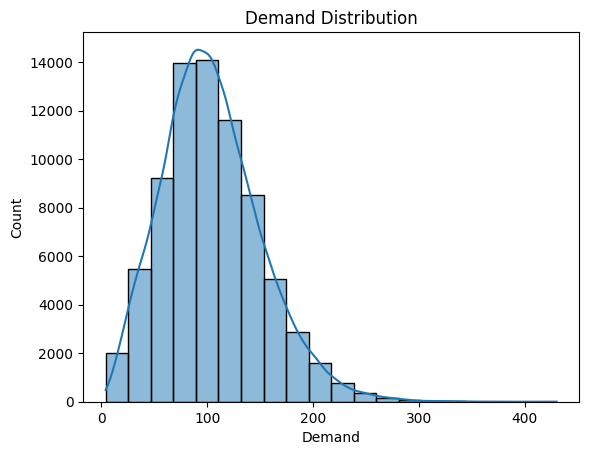

In [33]:
# --- Visualizations ---
# Demand distribution
sns.histplot(df["Demand"], bins=20, kde=True)
plt.title("Demand Distribution")
plt.show()

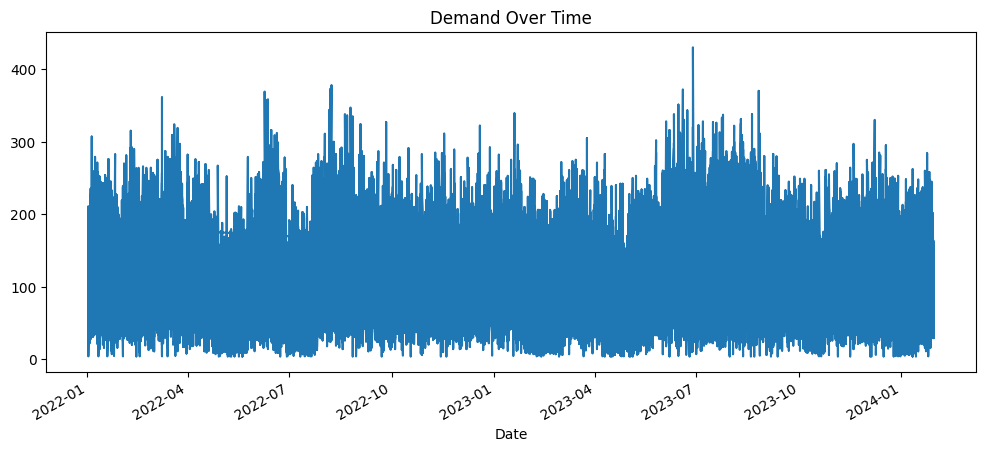

In [34]:
# Time trend 
df.set_index("Date")["Demand"].plot(figsize=(12,5), title="Demand Over Time")
plt.show()

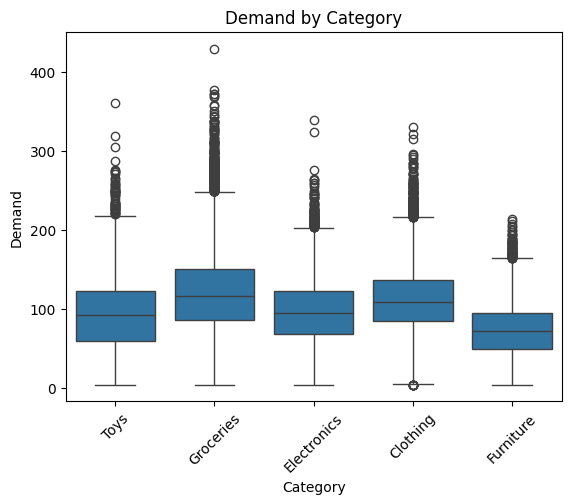

In [35]:
# Category analysis
sns.boxplot(data=df, x="Category", y="Demand")
plt.xticks(rotation=45)
plt.title("Demand by Category")
plt.show()


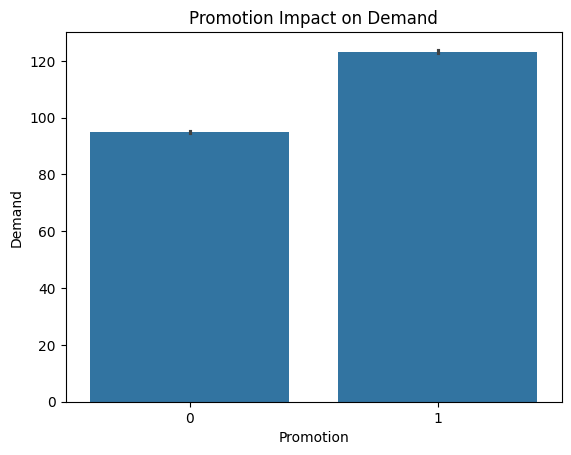

In [36]:
# Promotion impact
sns.barplot(data=df, x="Promotion", y="Demand")
plt.title("Promotion Impact on Demand")
plt.show()


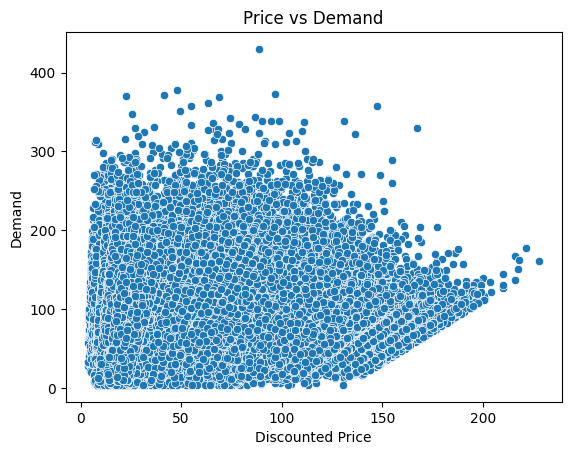

In [37]:
# Price vs Demand
sns.scatterplot(data=df, x="Discounted Price", y="Demand")
plt.title("Price vs Demand")
plt.show()


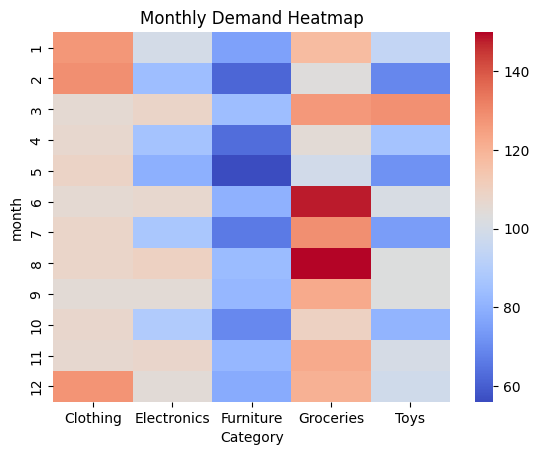

In [38]:
# Pivot heatmap
pivot = pd.pivot_table(df, values="Demand", index="month", columns="Category", aggfunc="mean")
sns.heatmap(pivot, cmap="coolwarm")
plt.title("Monthly Demand Heatmap")
plt.show()


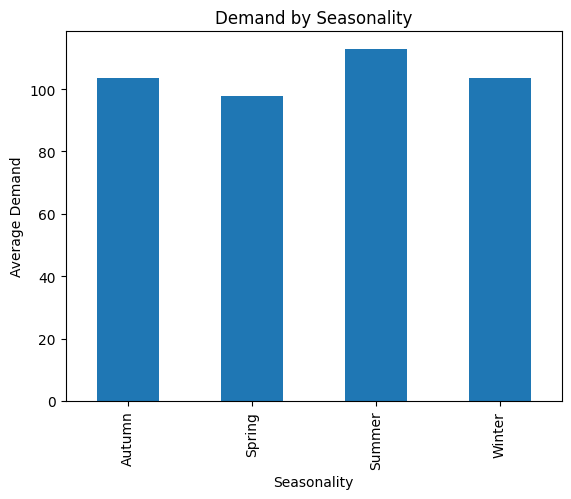

In [39]:
#Demand by Seasonality
df.groupby("Seasonality")["Demand"].mean().plot(kind="bar", title="Demand by Seasonality")
plt.ylabel("Average Demand")
plt.show()

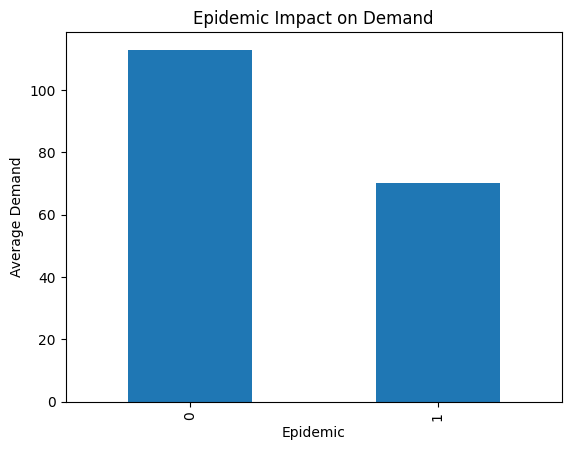

In [40]:
#Epidemic Impact
df.groupby("Epidemic")["Demand"].mean().plot(kind="bar", title="Epidemic Impact on Demand")
plt.ylabel("Average Demand")
plt.show()

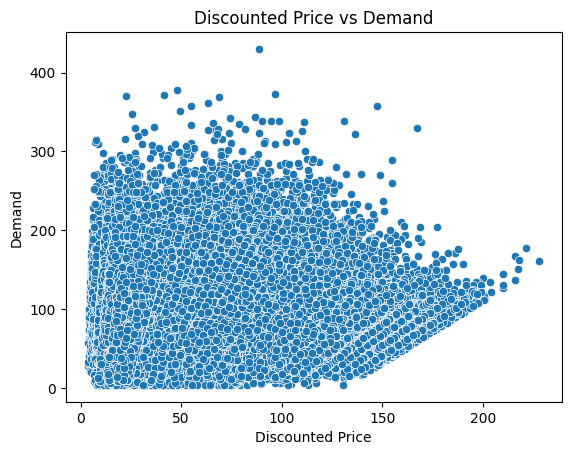

In [41]:
#Discounted Price vs Demand
sns.scatterplot(data=df, x="Discounted Price", y="Demand")
plt.title("Discounted Price vs Demand")
plt.show()

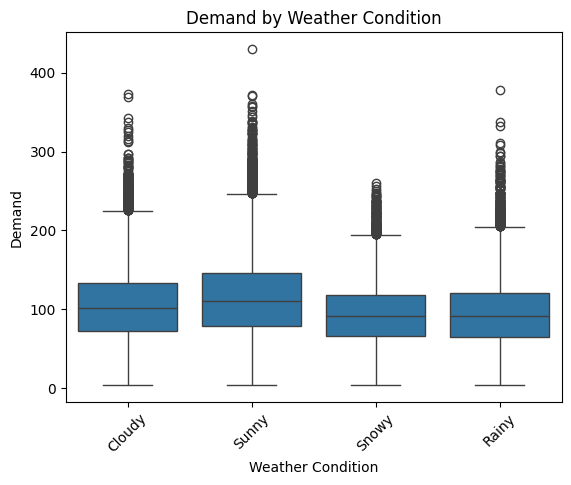

In [42]:
#Weather vs Demand
sns.boxplot(data=df, x="Weather Condition", y="Demand")
plt.xticks(rotation=45)
plt.title("Demand by Weather Condition")
plt.show()

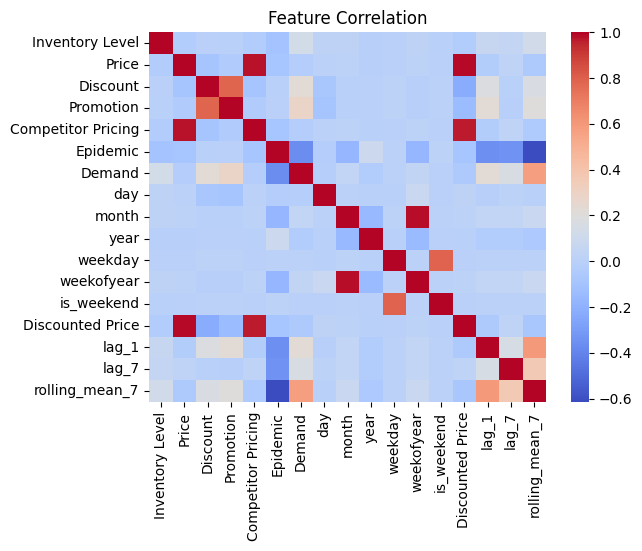

In [43]:
#Correlation heatmap
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

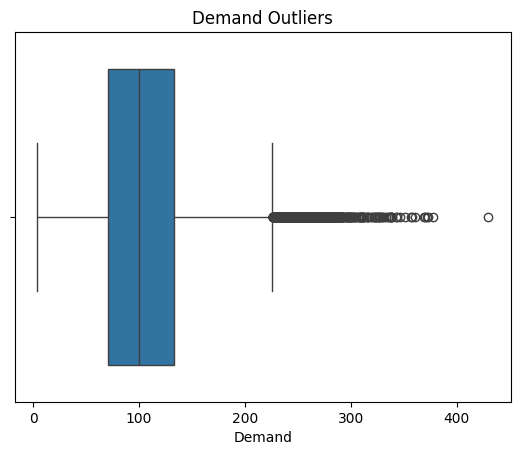

In [44]:
#Outlier check
sns.boxplot(x=df["Demand"])
plt.title("Demand Outliers")
plt.show()

In [45]:
df.to_csv("preprocessed_demand_forecasting_data.csv", index=False)

In [46]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Price,Discount,Weather Condition,Promotion,...,month,year,weekday,weekofyear,is_weekend,Discounted Price,lag_1,lag_7,rolling_mean_7,discount_bin
140,2022-01-02,S003,P0001,Toys,East,73,15.76,5,Cloudy,0,...,1,2022,6,52,1,14.9720,137.0,115.0,101.000000,"(0.0, 10.0]"
160,2022-01-02,S004,P0001,Groceries,West,130,12.67,10,Sunny,0,...,1,2022,6,52,1,11.4030,91.0,118.0,107.000000,"(0.0, 10.0]"
180,2022-01-02,S005,P0001,Groceries,North,107,11.70,0,Snowy,0,...,1,2022,6,52,1,11.7000,160.0,112.0,101.714286,NaN
200,2022-01-03,S001,P0001,Electronics,North,274,68.55,15,Snowy,1,...,1,2022,0,1,0,58.2675,75.0,81.0,109.000000,"(10.0, 20.0]"
220,2022-01-03,S002,P0001,Groceries,South,0,84.32,20,Cloudy,1,...,1,2022,0,1,0,67.4560,132.0,84.0,124.000000,"(10.0, 20.0]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75919,2024-01-30,S001,P0020,Furniture,North,333,112.50,5,Snowy,0,...,1,2024,1,5,0,106.8750,105.0,75.0,85.000000,"(0.0, 10.0]"
75939,2024-01-30,S002,P0020,Furniture,South,332,140.31,0,Snowy,0,...,1,2024,1,5,0,140.3100,73.0,130.0,78.142857,NaN
75959,2024-01-30,S003,P0020,Clothing,East,113,70.60,10,Sunny,0,...,1,2024,1,5,0,63.5400,82.0,72.0,81.571429,"(0.0, 10.0]"
75979,2024-01-30,S004,P0020,Furniture,West,79,132.53,10,Snowy,0,...,1,2024,1,5,0,119.2770,96.0,43.0,88.714286,"(0.0, 10.0]"


1. Load data
2. Convert Date
3. Basic checks
4. Feature engineering (day, month, etc.)
5. Discounted price
6. SORT (Product + Date)
7. Lag features (groupby Product)
8. Rolling mean (groupby Product)
9. Drop NaN
10. Remove leakage columns
11. EDA
12. Save dataset